In [10]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping


# =========================
# 1) Load dataset
# =========================
DATA_PATH = "processed_ecommerce_data.csv" 
TARGET = "Churn"
ID_COL = "CustomerID"  # drop if present

df = pd.read_csv(DATA_PATH)

X = df.drop(columns=[TARGET])
if ID_COL in X.columns:
    X = X.drop(columns=[ID_COL])
y = df[TARGET].astype(int)


# =========================
# 2) Train/test split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# =========================
# 3) Preprocessing (publicDataset style)
# =========================
num_cols = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder="drop"
)

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)


# =========================
# 4) SMOTE (train only)
# =========================
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_prep, y_train)


# =========================
# 5) Results helpers
# =========================
results = {}

def to_dense(x):
    return x.toarray() if hasattr(x, "toarray") else np.asarray(x)

def add_nn_results_with_cm(model_name, y_true, y_proba, results_dict):
    """
    Stores:
      results[model] = {
        "Classification Report": dict,
        "ROC AUC": float,
        "Confusion Matrix": np.array
      }
    Also plots the confusion matrix.
    """
    y_true = np.asarray(y_true).astype(int)
    y_proba = np.asarray(y_proba).ravel()
    y_pred = (y_proba >= 0.5).astype(int)

    rep = classification_report(y_true, y_pred, output_dict=True)
    auc = roc_auc_score(y_true, y_proba)
    cm  = confusion_matrix(y_true, y_pred)

    results_dict[model_name] = {
        "Classification Report": rep,
        "ROC AUC": auc,
        "Confusion Matrix": cm
    }

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(values_format="d", cmap="Blues")
    plt.title(f"Confusion Matrix – {model_name}")
    plt.show()

def build_metrics_table(results_dict):
    """
    publicDataset-style metrics table:
      Accuracy, Precision/Recall/F1 for positive class "1", ROC AUC
    """
    metrics_df = pd.DataFrame.from_dict(
        {
            model: {
                "Accuracy":  res["Classification Report"].get("accuracy", np.nan),
                "Precision": res["Classification Report"].get("1", {}).get("precision", np.nan),
                "Recall":    res["Classification Report"].get("1", {}).get("recall", np.nan),
                "F1-Score":  res["Classification Report"].get("1", {}).get("f1-score", np.nan),
                "ROC AUC":   res["ROC AUC"],
            }
            for model, res in results_dict.items()
        },
        orient="index"
    )
    return metrics_df.sort_values("ROC AUC", ascending=False)


# =========================
# 6) Prepare dense arrays for Keras
# =========================
Xtr = to_dense(X_train_res).astype("float32")
ytr = np.asarray(y_train_res).astype("float32")

Xte = to_dense(X_test_prep).astype("float32")
yte = np.asarray(y_test).astype("int32")

input_dim = Xtr.shape[1]

early = EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=5,
    restore_best_weights=True
)

c:\Users\Adithya\Desktop\public\.venv\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


## MLP (best-fit NN for tabular data without time series analysis)

Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - auc: 0.7210 - loss: 0.6920 - val_auc: 0.0000e+00 - val_loss: 0.6094
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - auc: 0.8985 - loss: 0.4135 - val_auc: 0.0000e+00 - val_loss: 0.5921
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - auc: 0.9179 - loss: 0.3591 - val_auc: 0.0000e+00 - val_loss: 0.5663
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - auc: 0.9407 - loss: 0.3057 - val_auc: 0.0000e+00 - val_loss: 0.5074
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - auc: 0.9454 - loss: 0.2910 - val_auc: 0.0000e+00 - val_loss: 0.4678
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - auc: 0.9561 - loss: 0.2646 - val_auc: 0.0000e+00 - val_loss: 0.4059
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


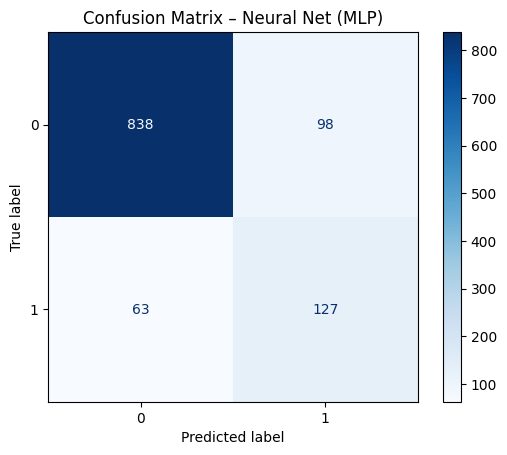

In [11]:
mlp = tf.keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid"),
])

mlp.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="auc")]
)

mlp.fit(
    Xtr, ytr,
    validation_split=0.2,
    epochs=50,
    batch_size=256,
    callbacks=[early],
    verbose=1
)

y_proba_mlp = mlp.predict(Xte).ravel()
add_nn_results_with_cm("Neural Net (MLP)", yte, y_proba_mlp, results)

## CNN1D (treat features as a 1D signal)

Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - auc: 0.6694 - loss: 0.6174 - val_auc: 0.0000e+00 - val_loss: 0.8418
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - auc: 0.8653 - loss: 0.4494 - val_auc: 0.0000e+00 - val_loss: 0.6493
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - auc: 0.9079 - loss: 0.3746 - val_auc: 0.0000e+00 - val_loss: 0.3860
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - auc: 0.9283 - loss: 0.3300 - val_auc: 0.0000e+00 - val_loss: 0.3327
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - auc: 0.9430 - loss: 0.2951 - val_auc: 0.0000e+00 - val_loss: 0.3974
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - auc: 0.9537 - loss: 0.2704 - val_auc: 0.0000e+00 - val_loss: 0.3721
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


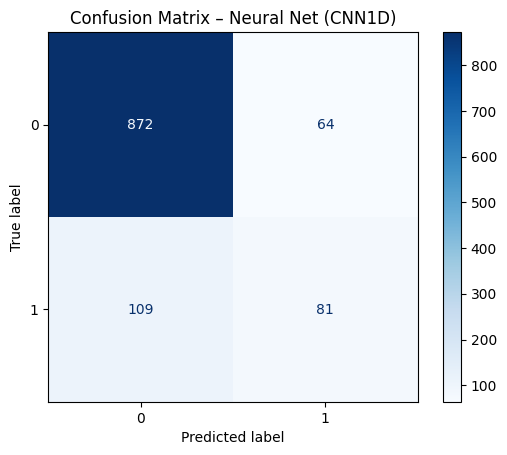

In [12]:
Xtr_cnn = Xtr.reshape(-1, input_dim, 1)
Xte_cnn = Xte.reshape(-1, input_dim, 1)

cnn = tf.keras.Sequential([
    layers.Input(shape=(input_dim, 1)),
    layers.Conv1D(64, kernel_size=5, activation="relu", padding="same"),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(128, kernel_size=5, activation="relu", padding="same"),
    layers.MaxPooling1D(pool_size=2),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid"),
])

cnn.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="auc")]
)

cnn.fit(
    Xtr_cnn, ytr,
    validation_split=0.2,
    epochs=50,
    batch_size=256,
    callbacks=[early],
    verbose=1
)

y_proba_cnn = cnn.predict(Xte_cnn).ravel()
add_nn_results_with_cm("Neural Net (CNN1D)", yte, y_proba_cnn, results)

## LSTM (treat features as a sequence)

Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - auc: 0.5153 - loss: 0.6756 - val_auc: 0.0000e+00 - val_loss: 0.9708
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - auc: 0.5577 - loss: 0.6550 - val_auc: 0.0000e+00 - val_loss: 0.9843
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - auc: 0.5997 - loss: 0.6469 - val_auc: 0.0000e+00 - val_loss: 0.8725
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - auc: 0.6882 - loss: 0.6255 - val_auc: 0.0000e+00 - val_loss: 0.7520
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - auc: 0.7502 - loss: 0.5713 - val_auc: 0.0000e+00 - val_loss: 0.8659
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - auc: 0.7784 - loss: 0.5477 - val_auc: 0.0000e+00 - val_loss: 0.7725
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


c:\Users\Adithya\Desktop\public\.venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Adithya\Desktop\public\.venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Adithya\Desktop\public\.venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


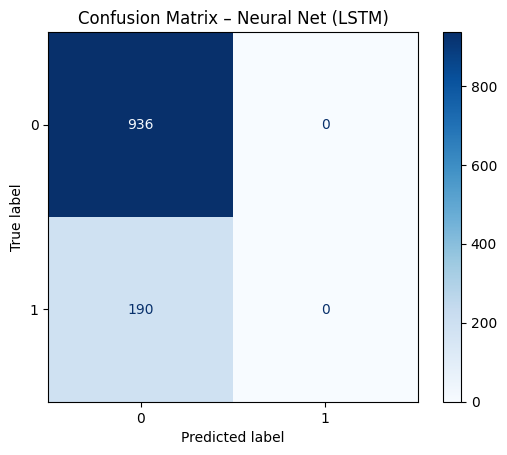

In [13]:
Xtr_lstm = Xtr.reshape(-1, input_dim, 1)
Xte_lstm = Xte.reshape(-1, input_dim, 1)

lstm = tf.keras.Sequential([
    layers.Input(shape=(input_dim, 1)),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(32),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid"),
])

lstm.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="auc")]
)

lstm.fit(
    Xtr_lstm, ytr,
    validation_split=0.2,
    epochs=50,
    batch_size=256,
    callbacks=[early],
    verbose=1
)

y_proba_lstm = lstm.predict(Xte_lstm).ravel()
add_nn_results_with_cm("Neural Net (LSTM)", yte, y_proba_lstm, results)

# Results

In [14]:
metrics_df = build_metrics_table(results)

metrics_df_rounded = metrics_df.copy()
for c in ["Accuracy", "Precision", "Recall", "F1-Score", "ROC AUC"]:
    metrics_df_rounded[c] = metrics_df_rounded[c].round(4)

print(metrics_df_rounded)

                    Accuracy  Precision  Recall  F1-Score  ROC AUC
Neural Net (MLP)      0.8570     0.5644  0.6684    0.6120   0.8767
Neural Net (CNN1D)    0.8464     0.5586  0.4263    0.4836   0.8096
Neural Net (LSTM)     0.8313     0.0000  0.0000    0.0000   0.5632
